# House Price Prediction — Model Notebook

In [1]:
import re
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

import sklearn
print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.6.1


## 1. Load & Inspect

In [2]:
df = pd.read_csv("house_prices.csv")
print(df.shape)
df.head()

(187531, 21)


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

In [4]:
df.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [5]:
df.isna().mean().sort_values(ascending=False)

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Title                0.000000
location             0.000000
Amount(in rupees)    0.000000
Index                0.000000
dtype: float64

The dataset has 187,531 rows and 21 columns. Most columns are text/object type; the true numeric
columns are Bathroom, Balcony, and Car Parking (though Bathroom/Balcony are stored as strings and
need type conversion). Price (in rupees) is numeric but mostly-null; Amount(in rupees) is the usable
text price column, with values like "42 Lac" or "1.40 Cr". Floor is also text, formatted like
"10 out of 11".

The columns with the most missing values are: Plot Area (100%), Dimensions (100%), Society (58.5%),
Super Area (57.4%), Car Parking (55.1%), overlooking (43.4%), and Carpet Area (43.0%).

## 2. Cleaning & Feature Engineering

In [6]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])
print(df.shape)

(177847, 22)


In [7]:
def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower().replace(",", "")
    match = re.search(r"[\d.]+", x)
    if not match:
        return None
    value = float(match.group())
    if "sqm" in x:
        value *= 10.764
    return value

df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)
df["super_area_sqft"] = df["Super Area"].apply(parse_area)
df["carpet_area_sqft"] = df["carpet_area_sqft"].fillna(df["super_area_sqft"])
df = df.dropna(subset=["carpet_area_sqft"])
print(df.shape)

(177757, 24)


In [8]:
def parse_floor(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    first_part = x.split("out of")[0].strip()
    if "ground" in first_part:
        return 0
    if "basement" in first_part:
        return -1
    match = re.search(r"\d+", first_part)
    return int(match.group()) if match else None

df["floor_num"] = df["Floor"].apply(parse_floor)

In [9]:
def parse_count(x):
    if pd.isna(x):
        return None
    if isinstance(x, str) and ">" in x:
        return int(x.replace(">", "").strip())
    try:
        return int(x)
    except (ValueError, TypeError):
        return None

for col in ["Bathroom", "Balcony"]:
    df[col] = df[col].apply(parse_count)
    df[col] = df[col].fillna(df[col].median())

df = df.rename(columns={"Bathroom": "bathroom", "Balcony": "balcony"})

In [10]:
TOP_N = 50
top_locations = df["location"].value_counts().head(TOP_N).index
df["location_grouped"] = df["location"].where(df["location"].isin(top_locations), "other")

In [11]:
df = df.drop(columns=[
    "Index", "Title", "Description", "Dimensions", "Plot Area",
    "Super Area", "Society", "overlooking", "Car Parking"
], errors="ignore")
print(df.shape)

(177757, 17)


In [12]:
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]
low, high = df["price_per_sqft"].quantile([0.01, 0.99])
df = df[(df["price_per_sqft"] >= low) & (df["price_per_sqft"] <= high)]
df = df.drop(columns=["price_per_sqft"])
print(df.shape)

(174471, 17)


## 3. Exploratory Data Analysis (EDA)


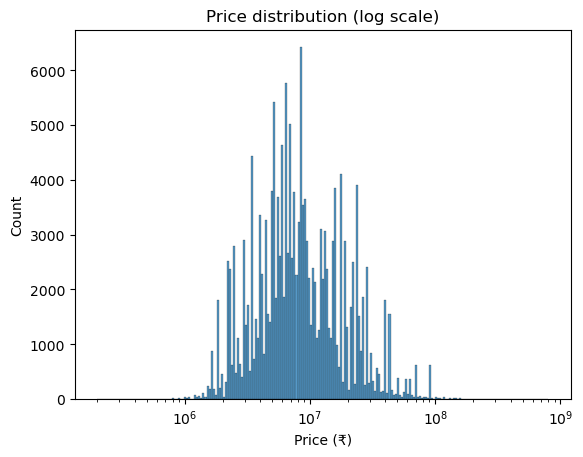

In [13]:
sns.histplot(df["price_clean"], log_scale=True)
plt.title("Price distribution (log scale)")
plt.xlabel("Price (\u20b9)")
plt.show()

*Observation: price is log-normal on the log scale, with a moderate tail of high-end listings.*

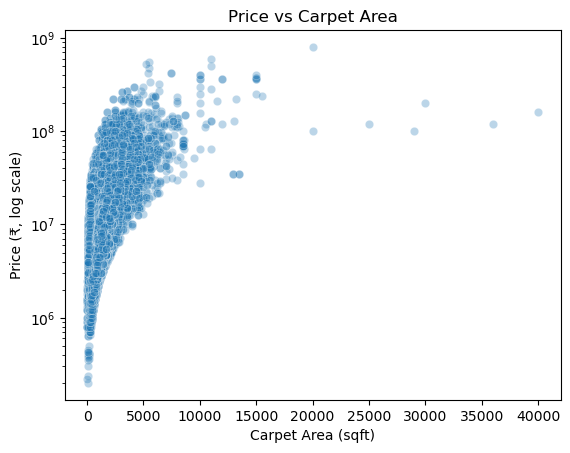

In [14]:
sns.scatterplot(x=df["carpet_area_sqft"], y=df["price_clean"], alpha=0.3)
plt.yscale("log")
plt.title("Price vs Carpet Area")
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (\u20b9, log scale)")
plt.show()

*Observation: price generally increases with carpet area, but with substantial scatter —
location and other features clearly explain a lot of the variance not captured by size alone.*

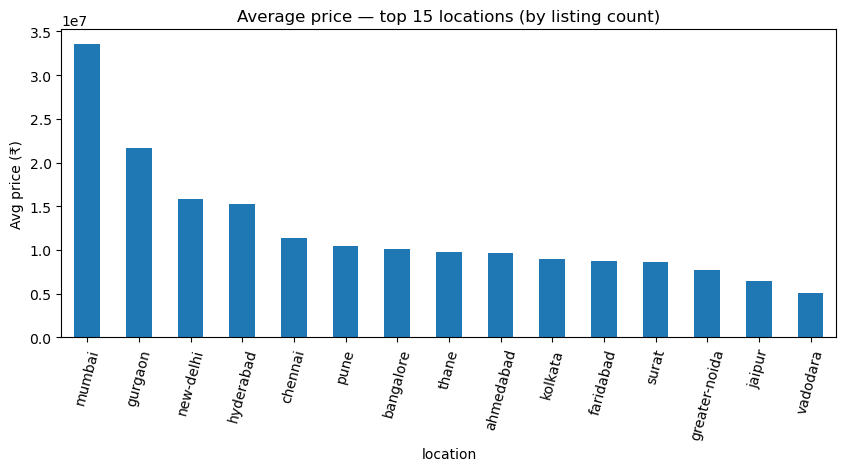

In [15]:
top_by_count = df["location"].value_counts().head(15).index
avg_by_loc = df[df["location"].isin(top_by_count)].groupby("location")["price_clean"].mean().sort_values(ascending=False)
avg_by_loc.plot(kind="bar", figsize=(10, 4))
plt.title("Average price — top 15 locations (by listing count)")
plt.ylabel("Avg price (₹)")
plt.xticks(rotation=75)
plt.show()

*Observation: average prices vary substantially by location, confirming location is an
important categorical feature to retain*

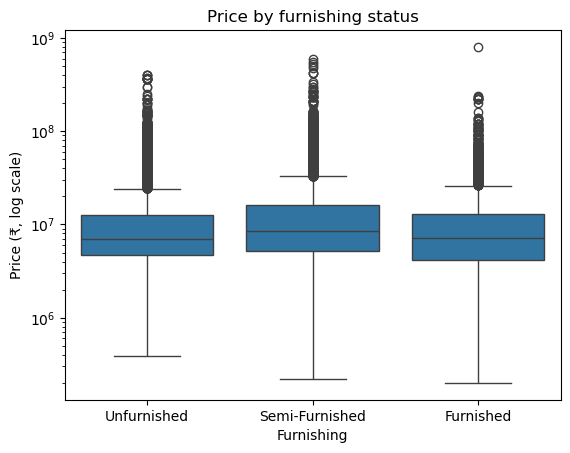

In [16]:
sns.boxplot(x=df["Furnishing"], y=df["price_clean"])
plt.yscale("log")
plt.title("Price by furnishing status")
plt.xlabel("Furnishing")
plt.ylabel("Price (\u20b9, log scale)")
plt.show()

*Observation: furnished properties tend to command a higher median price than unfurnished
ones, though the distributions overlap considerably.*

## 4. Build a Pipeline & Train

Uses a `ColumnTransformer` + `Pipeline` so all preprocessing (imputation, scaling,
one-hot encoding) is bundled inside the exported model.

In [17]:
numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                       ("scale", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                       ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["price_clean"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "linear_regression": Pipeline([("prep", preprocessor), ("reg", LinearRegression())]),
    "random_forest": Pipeline([("prep", preprocessor),
                                ("reg", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))]),
}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    print(f"Trained: {name}")

Trained: linear_regression
Trained: random_forest


## 5. Evaluate

In [18]:
results = {}
for name, pipe in models.items():
    pred = pipe.predict(X_test)
    results[name] = {
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": root_mean_squared_error(y_test, pred),
        "R2": r2_score(y_test, pred),
    }

results_df = pd.DataFrame(results).T
results_df

,MAE,RMSE,R2
linear_regression,4.540134e+06,8.459519e+06,0.616748
random_forest,1.021595e+06,5.391627e+06,0.844320


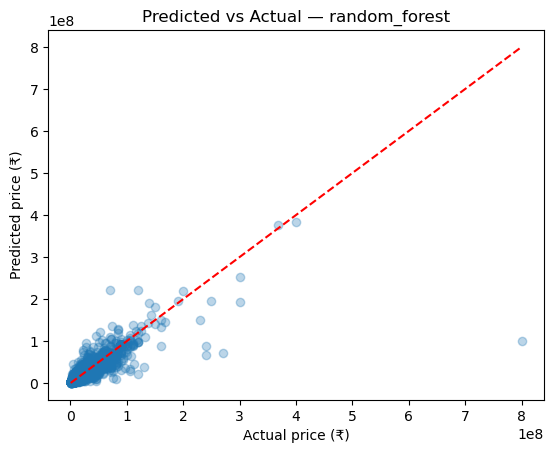

In [19]:
best_name = results_df["R2"].idxmax()
best_pred = models[best_name].predict(X_test)

plt.scatter(y_test, best_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual price (\u20b9)")
plt.ylabel("Predicted price (\u20b9)")
plt.title(f"Predicted vs Actual — {best_name}")
plt.show()

Comparing the two models, **random_forest** achieves a much higher R² (0.844 vs 0.617) and
lower MAE (₹1.02M vs ₹4.54M) and RMSE (₹5.39M vs ₹8.46M) on the test set than linear regression,
indicating it captures non-linear relationships between features (e.g. location, area, furnishing)
and price much better than a plain linear model. We select random_forest as the final model.

## 6. Export the Model

In [20]:
best_model = models[best_name]
joblib.dump(best_model, "house_price.pkl")

loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", loaded.predict(sample))

Reloaded prediction: [7000000.]


In [21]:
json.dump(sorted(df["location_grouped"].unique().tolist()), open("locations.json", "w"))
print("Saved locations.json with", df["location_grouped"].nunique(), "unique locations")

Saved locations.json with 51 unique locations
